In [34]:
import numpy as np
import pickle
from scipy.stats import sem
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
from matplotlib.lines import Line2D
import sys

sys.path.append("../../Modeling/fitting")
from optimization_utils import make_boundary

In [35]:
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVERES = False

In [50]:
# set np print options
np.set_printoptions(precision=3, suppress=True, linewidth=100)

## Load Stimuli and Semantic Matrix

In [36]:
with open("simu6a_data/simu6a_design.pkl", "rb") as inp:
    df_study = pickle.load(inp)
    df_test = pickle.load(inp)
df_study = df_study.loc[df_study.session < 100]  # for testing
df_test = df_test.loc[df_test.session < 100]  # for testing

In [37]:
df_study.query("session == 0 and list == 0")

,study_itemno1,study_itemno2,study_item1,study_item2,list,session
0,1569,1107,VINEGAR,PORCUPINE,0,0
1,30,696,APARTMENT,HEADBAND,0,0
2,1457,1443,THIGH,TECHNICIAN,0,0
3,1331,31,SNACK,APE,0,0
4,1377,1579,STEP,WAIST,0,0
5,681,468,HAMMOCK,DINNER,0,0


In [38]:
df_test.query("session == 0 and list == 0")

,test_itemno,test_item,correct_ans,lag,list,session,order
0,468,DINNER,681,0,0,0,2
1,1579,WAIST,1377,1,0,0,2
2,1331,SNACK,31,2,0,0,1
3,1457,THIGH,1443,3,0,0,1
4,696,HEADBAND,30,4,0,0,2
5,1569,VINEGAR,1107,5,0,0,1


In [39]:
sem_mat = np.load("../wordpools/ltp_FR_similarity_matrix.npy")

## Run CMR-IA

In [40]:
# # define parameters
# params = cmr.make_default_params()
# params.update(nitems_in_accumulator=48, use_new_context=True)

# # load pso results
# _, _, what_to_fit = make_boundary(sim_name="6a")
# optim_params = np.loadtxt("simu6a_data/6a_250303_200-200.txt")
# for pname, pvalue in zip(what_to_fit, optim_params):
#     params[pname] = pvalue
# params.update(beta_enc_inpair=0)
# params.update(gamma_fc=0.18, gamma_cf=0.18, s_fc=0, s_cf=0, c_thresh=0)
# params

In [89]:
# define parameters
params = cmr.make_default_params()
params.update(
    beta_enc=0.7,
    beta_cue=1,  # 0.55
    beta_distract=1,  # 0.01
    beta_rec_post=1,  # 0.99
    beta_rec=0,  # 0.5
    gamma_fc=0.28,
    gamma_cf=0.28,
    s_fc=0, # 0.1
    s_cf=0, # 0.1
    c_thresh=0.01,
    kappa=0.04,
    lamb=0.02,
    eta=0.01,
    alpha=0.9,
    omega=10,  # 3
    phi_s=0,  # 0.4
    phi_d=0,  # 1.3
    nitems_in_accumulator=48,
    use_new_context=True,
)
params.update(beta_enc_inpair=0.7)  # 0
params

{'beta_enc': 0.7,
 'beta_rec': 0,
 'beta_cue': 1,
 'beta_rec_post': 1,
 'beta_distract': 1,
 'beta_enc_inpair': 0.7,
 'phi_s': 0,
 'phi_d': 0,
 's_fc': 0,
 's_cf': 0,
 'kappa': 0.04,
 'eta': 0.01,
 'omega': 10,
 'alpha': 0.9,
 'lamb': 0.02,
 'c_thresh': 0.01,
 'c_thresh_itm': 0.5,
 'c_thresh_assoc': 0.5,
 'd_assoc': 0,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 48,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 0,
 'thresh_sigma': 0,
 'ban_recall': None,
 'use_var_enc': False,
 'var_enc_p': None,
 'bad_enc_ratio': None,
 'recog_slope': 1,
 'use_flexible_thresh': False,
 'thresh_rate': 0,
 'thresh_kernel_len': 10,
 'gamma_fc': 0.28,
 'gamma_cf': 0.28}

In [42]:
assert False

AssertionError: 

In [43]:
df_study = df_study.query("session == 0 and list == 0").iloc[0:3]
df_study

,study_itemno1,study_itemno2,study_item1,study_item2,list,session
0,1569,1107,VINEGAR,PORCUPINE,0,0
1,30,696,APARTMENT,HEADBAND,0,0
2,1457,1443,THIGH,TECHNICIAN,0,0


In [225]:
df_test = df_test.query("session == 0 and list == 0").iloc[0:1]
df_test

,test_itemno,test_item,correct_ans,lag,list,session,order
0,468,DINNER,681,0,0,0,2


In [90]:
task = "CR"
mode = "Final"

sessions = np.unique(df_study.session)
list_num = len(np.unique(df_study.list))
df_thin = df_test[["session", "list", "test_itemno"]]
resps, rts, csims = [], [], []
f_in, f_dif = [], []

for sess in sessions:
    # extarct the session data
    # pres_mat = df_study.loc[df_study.session == sess, ["study_itemno1", "study_itemno2"]].to_numpy()
    pres_mat = np.array([[1, 2], [3, 4], [5, 6]])
    pres_mat = np.reshape(pres_mat, (list_num, -1, 2))
    # cue_mat = df_thin.loc[df_thin.session == sess, "test_itemno"].to_numpy()
    cue_mat = np.array([6])
    cue_mat = np.reshape(cue_mat, (list_num, -1))

    # run CMR for each session
    cmr_model = cmr.CMR(params, pres_mat, sem_mat, cue_mat=cue_mat, task=task, mode=mode, seed=sess)
    cmr_model.run_norm_cr_single_sess()

    # save results
    resps += cmr_model.rec_items
    rts += cmr_model.rec_times
    csims += cmr_model.recog_csims
    f_in.append(cmr_model.f_in_acc)
    f_dif.append(cmr_model.f_in_dif)

# df_thin = df_thin.assign(s_resp=resps, s_rt=rts, csim=csims)

In [91]:
cmr_model.M_FC

array([[0.916, 0.14 , 0.1  , 0.071, 0.051, 0.036, 0.   , 0.   ],
       [0.   , 0.916, 0.14 , 0.1  , 0.071, 0.051, 0.   , 0.   ],
       [0.   , 0.   , 0.916, 0.14 , 0.1  , 0.071, 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.916, 0.14 , 0.1  , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.916, 0.14 , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.916, 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.72 , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.72 ]], dtype=float32)

In [92]:
cmr_model.M_CF

array([[0.916, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.14 , 0.916, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.1  , 0.14 , 0.916, 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.071, 0.1  , 0.14 , 0.916, 0.   , 0.   , 0.   , 0.   ],
       [0.051, 0.071, 0.1  , 0.14 , 0.916, 0.   , 0.   , 0.   ],
       [0.036, 0.051, 0.071, 0.1  , 0.14 , 0.916, 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.72 , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.72 ]], dtype=float32)

In [93]:
np.linalg.norm(cmr_model.M_CF[4, :]), np.linalg.norm(cmr_model.M_CF[5, :])

(0.93612766, 0.93683535)

In [62]:
cmr_model.c.flatten()

array([0.131, 0.   , 0.183, 0.   , 0.256, 0.94 , 0.   , 0.   ], dtype=float32)

In [94]:
np.linalg.norm(cmr_model.M_FC[:, 4]), np.linalg.norm(cmr_model.M_FC[:, 5])

(0.93612766, 0.93683535)

In [96]:
# cue 5, retrieve 6
np.dot(cmr_model.M_FC[:, 4], cmr_model.M_CF[5, :]) / np.linalg.norm(cmr_model.M_FC[:, 4])

0.16540147

In [95]:
# cue 6, retrieve 5
np.dot(cmr_model.M_FC[:, 5], cmr_model.M_CF[4, :]) / np.linalg.norm(cmr_model.M_FC[:, 5]) 

0.16527653

In [97]:
f_in

[[array([0.036, 0.055, 0.081, 0.117, 0.165, 0.937], dtype=float32)]]

In [ ]:
assert False

In [82]:
task = "CR"
mode = "Final"

sessions = np.unique(df_study.session)
list_num = len(np.unique(df_study.list))
df_thin = df_test[["session", "list", "test_itemno"]]
resps, rts, csims = [], [], []
f_in, f_dif = [], []

for sess in sessions:
    # extarct the session data
    # pres_mat = df_study.loc[df_study.session == sess, ["study_itemno1", "study_itemno2"]].to_numpy()
    pres_mat = np.array([[1, 2]])
    pres_mat = np.reshape(pres_mat, (list_num, -1, 2))
    # cue_mat = df_thin.loc[df_thin.session == sess, "test_itemno"].to_numpy()
    cue_mat = np.array([2])
    cue_mat = np.reshape(cue_mat, (list_num, -1))

    # run CMR for each session
    cmr_model = cmr.CMR(params, pres_mat, sem_mat, cue_mat=cue_mat, task=task, mode=mode, seed=sess)
    cmr_model.run_norm_cr_single_sess()

    # save results
    resps += cmr_model.rec_items
    rts += cmr_model.rec_times
    csims += cmr_model.recog_csims
    f_in.append(cmr_model.f_in_acc)
    f_dif.append(cmr_model.f_in_dif)

# df_thin = df_thin.assign(s_resp=resps, s_rt=rts, csim=csims)

In [83]:
cmr_model.M_FC

array([[0.916, 0.196, 0.   , 0.   ],
       [0.   , 0.72 , 0.   , 0.   ],
       [0.   , 0.   , 0.72 , 0.   ],
       [0.   , 0.   , 0.   , 0.72 ]], dtype=float32)

In [84]:
cmr_model.M_CF

array([[0.916, 0.   , 0.   , 0.   ],
       [0.196, 0.72 , 0.   , 0.   ],
       [0.   , 0.   , 0.72 , 0.   ],
       [0.   , 0.   , 0.   , 0.72 ]], dtype=float32)

In [85]:
np.linalg.norm(cmr_model.M_CF[0, :]), np.linalg.norm(cmr_model.M_CF[1, :])

(0.916, 0.74620104)

In [86]:
np.dot(cmr_model.M_FC[:, 0], cmr_model.M_CF[1, :]) / np.linalg.norm(cmr_model.M_FC[:, 0]) 

0.196

In [87]:
np.dot(cmr_model.M_FC[:, 1], cmr_model.M_CF[0, :]) / np.linalg.norm(cmr_model.M_FC[:, 1])

0.24060003

In [88]:
f_in

[[array([0.241, 0.746], dtype=float32)]]

In [ ]:
assert False

In [9]:
# run CMR-IA
df_simu, f_in, f_dif = cmr.run_norm_cr_multi_sess(params, df_study, df_test, sem_mat)
df_simu

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [02:34<00:00,  1.55s/it]

CMR Time: 154.76090717315674


,session,list,test_itemno,s_resp,s_rt,csim
0,0,0,468,681,4680,0.301760
1,0,0,1579,1377,4510,0.300487
2,0,0,1331,-1,-1,-1.000000
3,0,0,1457,-1,-1,-1.000000
4,0,0,696,-1,-1,-1.000000
...,...,...,...,...,...,...
25195,99,41,63,-1,-1,-1.000000
25196,99,41,299,-1,-1,-1.000000
25197,99,41,323,-1,-1,-1.000000
25198,99,41,239,-1,-1,-1.000000


In [10]:
# merge to get more info
df_simu = df_simu.merge(df_test, on=["session", "list", "test_itemno"])
df_simu["correct"] = df_simu.s_resp == df_simu.correct_ans
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,lag,order,correct
0,0,0,468,681,4680,0.301760,DINNER,681,0,2,True
1,0,0,1579,1377,4510,0.300487,WAIST,1377,1,2,True
2,0,0,1331,-1,-1,-1.000000,SNACK,31,2,1,False
3,0,0,1457,-1,-1,-1.000000,THIGH,1443,3,1,False
4,0,0,696,-1,-1,-1.000000,HEADBAND,30,4,2,False
...,...,...,...,...,...,...,...,...,...,...,...
25195,99,41,63,-1,-1,-1.000000,AWARD,504,1,2,False
25196,99,41,299,-1,-1,-1.000000,CHILD,1369,2,1,False
25197,99,41,323,-1,-1,-1.000000,CLIMBER,787,3,1,False
25198,99,41,239,-1,-1,-1.000000,CAPTAIN,1352,4,2,False


In [11]:
# merge f_in info, for testing
sessions = np.unique(df_simu.session)
for sess in sessions:
    df_tmp = df_study.loc[df_study.session == sess]
    tmp1 = df_tmp.study_itemno1.to_numpy()
    tmp2 = df_tmp.study_itemno2.to_numpy()
    tmp = np.concatenate((tmp1, tmp2))
    tmp = np.sort(tmp)
    tmp_test = df_simu.loc[df_study.session == sess, "test_itemno"]
    tmp_corr = df_simu.loc[df_study.session == sess, "correct_ans"]
    testid = np.searchsorted(tmp, tmp_test)
    corrid = np.searchsorted(tmp, tmp_corr)

    df_simu.loc[df_simu.session == sess, "corr_fin"] = [f_dif[sess][i][id] for i, id in enumerate(corrid)]
    # df_simu.loc[df_simu.session == sess, 'omean_fin'] = [np.mean(np.delete(f_dif[sess][i], id)) for i, id in corrid]
    df_simu.loc[df_simu.session == sess, "omax_fin"] = [np.max(np.delete(f_dif[sess][i], id)) for i, id in enumerate(corrid)]
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,lag,order,correct,corr_fin,omax_fin
0,0,0,468,681,4680,0.301760,DINNER,681,0,2,True,-0.717301,-0.799339
1,0,0,1579,1377,4510,0.300487,WAIST,1377,1,2,True,-0.718705,-0.801523
2,0,0,1331,-1,-1,-1.000000,SNACK,31,2,1,False,-0.770828,-0.840232
3,0,0,1457,-1,-1,-1.000000,THIGH,1443,3,1,False,-0.775624,-0.839764
4,0,0,696,-1,-1,-1.000000,HEADBAND,30,4,2,False,-0.737719,-0.831123
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25195,99,41,63,-1,-1,-1.000000,AWARD,504,1,2,False,-0.718705,-0.801523
25196,99,41,299,-1,-1,-1.000000,CHILD,1369,2,1,False,-0.770828,-0.836338
25197,99,41,323,-1,-1,-1.000000,CLIMBER,787,3,1,False,-0.775624,-0.839764
25198,99,41,239,-1,-1,-1.000000,CAPTAIN,1352,4,2,False,-0.737719,-0.831123


In [12]:
# if SAVERES:
#     df_simu.to_pickle("simu6a_data/simu6a_result.pkl")

## Analysis

In [13]:
# with open("simu6a_data/simu6a_result.pkl", "rb") as inp:
#     df_simu = pickle.load(inp)

In [14]:
# clean first 2 list
df_simu = df_simu.query("list > 1")
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,lag,order,correct,corr_fin,omax_fin
12,0,2,887,-1,-1,-1.000000,MERMAID,816,0,1,False,-0.767152,-0.834723
13,0,2,10,-1,-1,-1.000000,AGENT,1101,1,1,False,-0.768392,-0.834599
14,0,2,1411,-1,-1,-1.000000,SUPPER,1561,2,2,False,-0.721467,-0.805820
15,0,2,959,-1,-1,-1.000000,NOTEBOOK,1104,3,2,False,-0.726914,-0.814296
16,0,2,1448,969,4710,0.283048,TEMPLE,969,4,2,True,-0.737719,-0.831123
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25195,99,41,63,-1,-1,-1.000000,AWARD,504,1,2,False,-0.718705,-0.801523
25196,99,41,299,-1,-1,-1.000000,CHILD,1369,2,1,False,-0.770828,-0.836338
25197,99,41,323,-1,-1,-1.000000,CLIMBER,787,3,1,False,-0.775624,-0.839764
25198,99,41,239,-1,-1,-1.000000,CAPTAIN,1352,4,2,False,-0.737719,-0.831123


### f_IN

In [15]:
df_fin = df_simu.groupby("lag")[["corr_fin", "omax_fin"]].mean().reset_index()
df_fin["dif"] = df_fin["corr_fin"] - df_fin["omax_fin"]
df_fin

,lag,corr_fin,omax_fin,dif
0,0,-0.742015,-0.816881,0.074866
1,1,-0.758785,-0.818444,0.059659
2,2,-0.768364,-0.821315,0.052952
3,3,-0.776123,-0.827824,0.051701
4,4,-0.774540,-0.840490,0.065950
5,5,-0.791477,-0.916095,0.124618


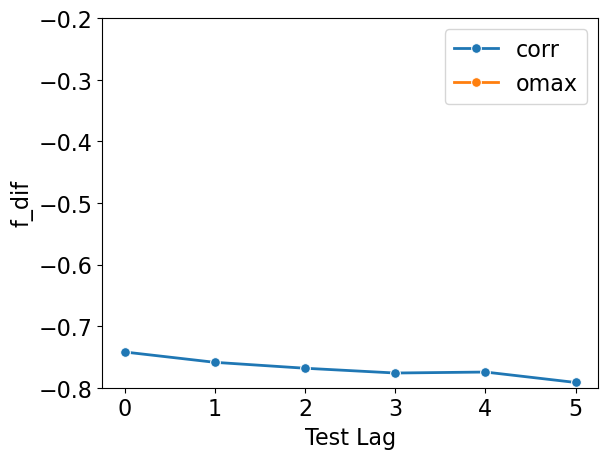

In [16]:
sns.lineplot(data=df_fin, x="lag", y="corr_fin", linewidth=2, marker="o", markersize=7, label="corr")
# sns.lineplot(data=df_fin, x='lag', y='omean_fin', linewidth=2, marker='o', markersize = 7)
sns.lineplot(data=df_fin, x="lag", y="omax_fin", linewidth=2, marker="o", markersize=7, label="omax")
plt.ylim([-0.8, -0.2])
plt.xlabel("Test Lag")
plt.ylabel("f_dif")
plt.show()

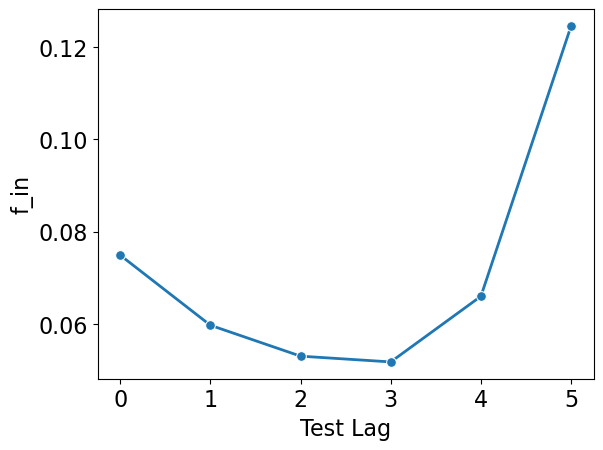

In [17]:
sns.lineplot(data=df_fin, x="lag", y="dif", linewidth=2, marker="o", markersize=7)
# plt.ylim([0,1])
plt.xlabel("Test Lag")
plt.ylabel("f_in")
plt.show()

In [18]:
df_fin = df_simu.groupby(["lag", "order"])[["corr_fin", "omax_fin"]].mean().reset_index()
# df_fin["dif"] = df_fin["corr_fin"] - df_fin["omax_fin"]
df_fin

,lag,order,corr_fin,omax_fin
0,0,1,-0.767152,-0.834723
1,0,2,-0.717301,-0.799339
2,1,1,-0.768392,-0.835045
3,1,2,-0.748993,-0.801523
4,2,1,-0.770828,-0.837171
5,2,2,-0.765956,-0.805820
6,3,1,-0.775624,-0.841481
7,3,2,-0.776616,-0.814329
8,4,1,-0.785106,-0.849374
9,4,2,-0.763399,-0.831123


### Yes rate

In [19]:
# session-wise, calculate correct rate for each condition
df_sess_lag = df_simu.groupby(["session", "lag", "order"]).correct.mean().to_frame(name="correct_rate").reset_index()
df_sess_lag

,session,lag,order,correct_rate
0,0,0,1,0.000000
1,0,0,2,0.333333
2,0,1,1,0.000000
3,0,1,2,0.315789
4,0,2,1,0.150000
...,...,...,...,...
1195,99,3,2,0.250000
1196,99,4,1,0.080000
1197,99,4,2,0.200000
1198,99,5,1,0.000000


In [20]:
# collapse across sessions
df_lag = df_sess_lag.groupby(["lag", "order"]).correct_rate.mean().to_frame(name="correct_rate").reset_index()
df_lag

,lag,order,correct_rate
0,0,1,0.056487
1,0,2,0.347408
2,1,1,0.048293
3,1,2,0.335063
4,2,1,0.040459
5,2,2,0.330820
6,3,1,0.026890
7,3,2,0.301345
8,4,1,0.018733
9,4,2,0.235233


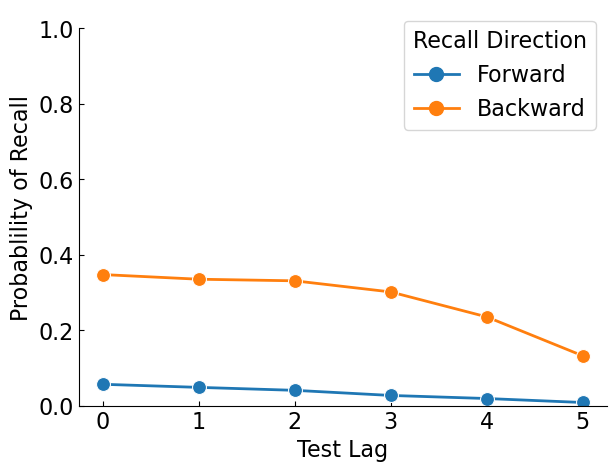

In [21]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines["left"].set_bounds(0, 1)
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_lag, x="lag", y="correct_rate", linewidth=2, marker="o", markersize=10, hue="order", palette="tab10")
plt.ylim([0, 1.05])
plt.xlabel("Test Lag")
plt.ylabel("Probablility of Recall")

legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="-", label="Forward"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="-", label="Backward"),
]
L = plt.legend(handles=legend_elements, title="Recall Direction", loc="upper right")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("simu6a_fig/simu6a_recall.pdf")

### Error Check

In [30]:
with open("simu6a_data/simu6a_gt.pkl", "rb") as f:
    fw_gt = pickle.load(f)
    bw_gt = pickle.load(f)

fw = df_lag.query("order == 1").correct_rate.values
bw = df_lag.query("order == 2").correct_rate.values
err = np.power(fw - fw_gt, 2).sum() + np.power(bw - bw_gt, 2).sum()
err

1.4446459404254162

In [31]:
fw, bw

(array([0.99024731, 0.00265635, 0.        , 0.        , 0.        ,
        0.        ]),
 array([0.99941176, 0.06696534, 0.        , 0.        , 0.        ,
        0.        ]))

## Multiple Tests

In [32]:
betas = [-1, 0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

fws, bws, fw_bws = [], [], []
for beta_enc_inpair in betas:

    # run
    params.update(beta_enc_inpair=beta_enc_inpair)
    df_simu, _, _ = cmr.run_norm_cr_multi_sess(params, df_study, df_test, sem_mat)

    # merge to get more info
    df_simu = df_simu.merge(df_test, on=["session", "list", "test_itemno"])
    df_simu["correct"] = df_simu.s_resp == df_simu.correct_ans

    # clean first 2 list
    df_simu = df_simu.query("list > 1")

    # session-wise, calculate correct rate for each condition
    df_sess_lag = df_simu.groupby(["session", "lag", "order"]).correct.mean().to_frame(name="correct_rate").reset_index()

    # collapse across sessions
    df_lag = df_sess_lag.groupby(["lag", "order"]).correct_rate.mean().to_frame(name="correct_rate").reset_index()

    fw = df_lag.query("order == 1").correct_rate.values
    bw = df_lag.query("order == 2").correct_rate.values
    fw_bw = fw - bw
    fws.append(fw)
    bws.append(bw)
    fw_bws.append(fw_bw)

100%|██████████| 100/100 [02:11<00:00,  1.31s/it]


CMR Time: 131.4294092655182


 18%|█▊        | 18/100 [00:26<02:02,  1.50s/it]


KeyboardInterrupt: 

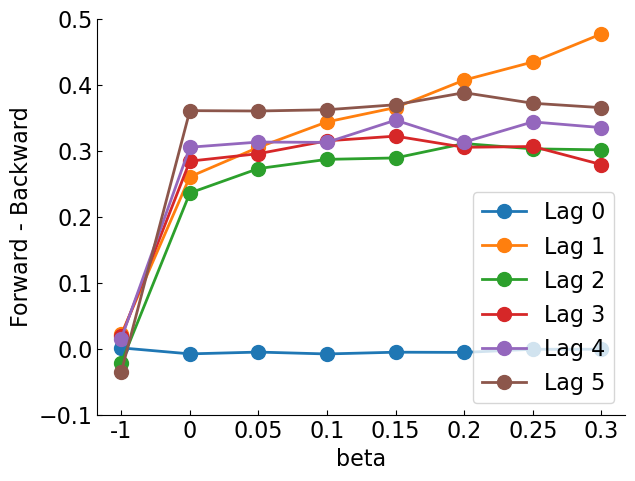

In [ ]:
# plot each column of fw_bws
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)
ax.spines["left"].set_bounds(-0.1, 0.5)
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
for i in range(6):
    ax.plot(np.array(fw_bws)[:, i], linewidth=2, marker="o", markersize=10, label=f"Lag {i}")
plt.ylim([-0.1, 0.5])
plt.xlabel("beta")
plt.ylabel("Forward - Backward")
plt.xticks(ticks=range(len(betas)), labels=betas)
plt.legend()

In [ ]:
fw_bws

[array([ 0.00106659,  0.02175798, -0.02142558,  0.01835784,  0.01526957,
        -0.03544524]),
 array([-0.00801902,  0.26032749,  0.23574392,  0.28401031,  0.30509892,
         0.36051827]),
 array([-0.00530033,  0.30498219,  0.2727527 ,  0.2953083 ,  0.31291713,
         0.35996444]),
 array([-0.00813562,  0.34347629,  0.28668634,  0.3147818 ,  0.31243235,
         0.36188504]),
 array([-0.00547423,  0.36522054,  0.28885125,  0.32188611,  0.34609415,
         0.36945462]),
 array([-0.00580264,  0.40678841,  0.31064226,  0.3049862 ,  0.31275577,
         0.38774901]),
 array([-0.00105228,  0.43421602,  0.30263132,  0.30618836,  0.34348783,
         0.37172933]),
 array([-0.00099759,  0.47668005,  0.30109852,  0.27882404,  0.33480716,
         0.36504198])]